In [ ]:
# 1. 구글 코랩 한글 폰트 설치 및 초기화
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import os
import math
import warnings
import logging
import pickle
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.cluster import DBSCAN
from scipy.spatial import KDTree

# 경고 문구 및 폰트 로그 차단
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 나눔고딕 강제 지정 (런타임 재시작 없이 반영)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,421 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and dire

In [ ]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

# 데이터 파일 경로 설정
file_path = '/content/drive/MyDrive/ACK2026_Wafer/MIR-WM811K/MIR-WM811K/Python/WM811K_defects.pkl'

# 데이터프레임 로드
print("🔄 데이터셋 로드 중...")
df_defects = pd.read_pickle(file_path)

# 웨이퍼 맵 면적 계산 (추후 패턴별 전처리 시 활용 가능)
df_defects['wafer_area'] = df_defects['waferMap'].apply(lambda x: x.shape[0] * x.shape[1])

print(f"✅ 데이터 로드 완료, 총 {len(df_defects)}개의 웨이퍼 맵 확보")

Mounted at /content/drive
🔄 데이터셋 로드 중...
✅ 데이터 로드 완료, 총 25519개의 웨이퍼 맵 확보


In [ ]:
# 결함 보존형 통합 전처리 클래스
class WaferPreprocessor:
    def __init__(self, eps=0.10, min_samples=3, edge_radius=0.08, r_bins=64, theta_bins=64):
        self.eps = eps
        self.min_samples = min_samples
        self.edge_radius = edge_radius
        self.r_bins = r_bins
        self.theta_bins = theta_bins

    def process_wafer(self, wafer_map):
        # 1. 불량(2) 좌표 추출
        bad_y, bad_x = np.where(wafer_map == 2)
        raw_coords = np.column_stack((bad_x, bad_y))
        if len(raw_coords) == 0: return None

        # 2. 정규화 ([-1, 1] 범위로 변환)
        h, w = wafer_map.shape
        cx, cy = w / 2.0, h / 2.0
        rmax = max(cx, cy)
        x_norm = (raw_coords[:, 0] - cx) / rmax
        y_norm = -(raw_coords[:, 1] - cy) / rmax
        normalized_coords = np.column_stack((x_norm, y_norm))

        # 3. DBSCAN 노이즈 제거 (단순화: 산발적 잡음인 -1만 제거하고 모든 유효 군집 보존)
        db = DBSCAN(eps=self.eps, min_samples=self.min_samples).fit(normalized_coords)
        labels = db.labels_

        # 노이즈(-1)가 아닌 모든 점을 유효 결함으로 인정하여 Edge-Ring 및 다중 결함 보존
        valid_mask = (labels != -1)
        clean_coords = normalized_coords[valid_mask]

        # 만약 노이즈 제거로 인해 남은 점이 너무 없으면 원본 좌표를 Fallback으로 사용하여 데이터 소실 방지
        if len(clean_coords) < 3:
            clean_coords = normalized_coords

        # 4. GCN 데이터(그래프) 및 CNN 데이터(극좌표) 생성
        graph_x, edge_index = self._build_graph_structure(clean_coords)
        polar_image = self._build_polar_image(clean_coords)

        return {
            'graph_x': graph_x, 'edge_index': edge_index, 'polar_image': polar_image
        }

    def _build_graph_structure(self, coords):
        graph_x = torch.tensor(coords, dtype=torch.float32)
        tree = KDTree(coords)
        pairs = tree.query_pairs(r=self.edge_radius)
        if len(pairs) == 0: return graph_x, torch.empty((2, 0), dtype=torch.long)
        edges = np.array(list(pairs)).T
        edge_index = torch.tensor(edges, dtype=torch.long)
        edge_index = torch.cat([edge_index, edge_index[[1, 0]]], dim=1) # 양방향 에지
        return graph_x, edge_index

    def _build_polar_image(self, coords):
        polar_grid = torch.zeros((1, self.r_bins, self.theta_bins), dtype=torch.float32)
        r = np.sqrt(coords[:, 0]**2 + coords[:, 1]**2)
        theta = np.arctan2(coords[:, 1], coords[:, 0])
        r_indices = np.clip((r * (self.r_bins - 1)).astype(int), 0, self.r_bins - 1)
        theta_indices = np.clip(((theta + math.pi) / (2 * math.pi) * (self.theta_bins - 1)).astype(int), 0, self.theta_bins - 1)
        polar_grid[0, r_indices, theta_indices] = 1.0
        return polar_grid

print("✅ 전처리 클래스 정의 완료")

✅ 전처리 클래스 정의 완료


In [ ]:
# 모든 결함에 동일하게 단일 파라미터 적용
UNIFIED_EPS = 0.10
UNIFIED_MIN_SAMPLES = 4
UNIFIED_EDGE_RADIUS = 0.08

In [ ]:
# 전체 데이터셋 자동 전처리 및 결과 저장 (단일 파라미터 적용)
final_data = []

print("전체 데이터셋 전처리 시작...")
for idx, row in df_defects.iterrows():
    f_type = row['failureType']

    # 패턴별 딕셔너리 대신 위에서 정의한 단일 파라미터 투입
    preprocessor = WaferPreprocessor(
        eps=UNIFIED_EPS,
        min_samples=UNIFIED_MIN_SAMPLES,
        edge_radius=UNIFIED_EDGE_RADIUS
    )

    # 전처리 엔진 가동
    processed = preprocessor.process_wafer(row['waferMap'])

    # 유효한 결함이 추출된 경우만 데이터셋에 추가
    if processed is not None:
        processed['failureType'] = f_type
        processed['original_index'] = idx
        final_data.append(processed)

    # 진행 상황 모니터링 (500개 단위 출력)
    if (idx + 1) % 500 == 0:
        print(f"진행 상황: {idx + 1} / {len(df_defects)} 완료")

# 딥러닝 학습용 바이너리 파일로 직렬화 저장
with open('final_training_data.pkl', 'wb') as f:
    pickle.dump(final_data, f)

print(f"전처리 완료. 총 {len(final_data)}개의 학습 데이터가 저장되었습니다.")

전체 데이터셋 전처리 시작...
진행 상황: 2000 / 25519 완료
진행 상황: 12500 / 25519 완료
진행 상황: 19500 / 25519 완료
진행 상황: 21000 / 25519 완료
진행 상황: 21500 / 25519 완료
진행 상황: 58500 / 25519 완료
진행 상황: 76000 / 25519 완료
진행 상황: 88500 / 25519 완료
진행 상황: 89500 / 25519 완료
진행 상황: 150500 / 25519 완료
진행 상황: 200000 / 25519 완료
진행 상황: 201000 / 25519 완료
진행 상황: 204000 / 25519 완료
진행 상황: 205500 / 25519 완료
진행 상황: 223500 / 25519 완료
진행 상황: 242000 / 25519 완료
진행 상황: 279500 / 25519 완료
진행 상황: 280000 / 25519 완료
진행 상황: 329500 / 25519 완료
진행 상황: 344000 / 25519 완료
진행 상황: 347000 / 25519 완료
진행 상황: 350500 / 25519 완료
진행 상황: 353500 / 25519 완료
진행 상황: 358500 / 25519 완료
진행 상황: 360000 / 25519 완료
진행 상황: 362000 / 25519 완료
진행 상황: 387500 / 25519 완료
진행 상황: 394500 / 25519 완료
진행 상황: 397500 / 25519 완료
진행 상황: 417000 / 25519 완료
진행 상황: 439500 / 25519 완료
진행 상황: 493500 / 25519 완료
진행 상황: 587500 / 25519 완료
진행 상황: 588000 / 25519 완료
진행 상황: 592000 / 25519 완료
진행 상황: 608500 / 25519 완료
진행 상황: 641000 / 25519 완료
진행 상황: 680500 / 25519 완료
진행 상황: 682500 / 25519 완료
진행 상황: 684000 / 2

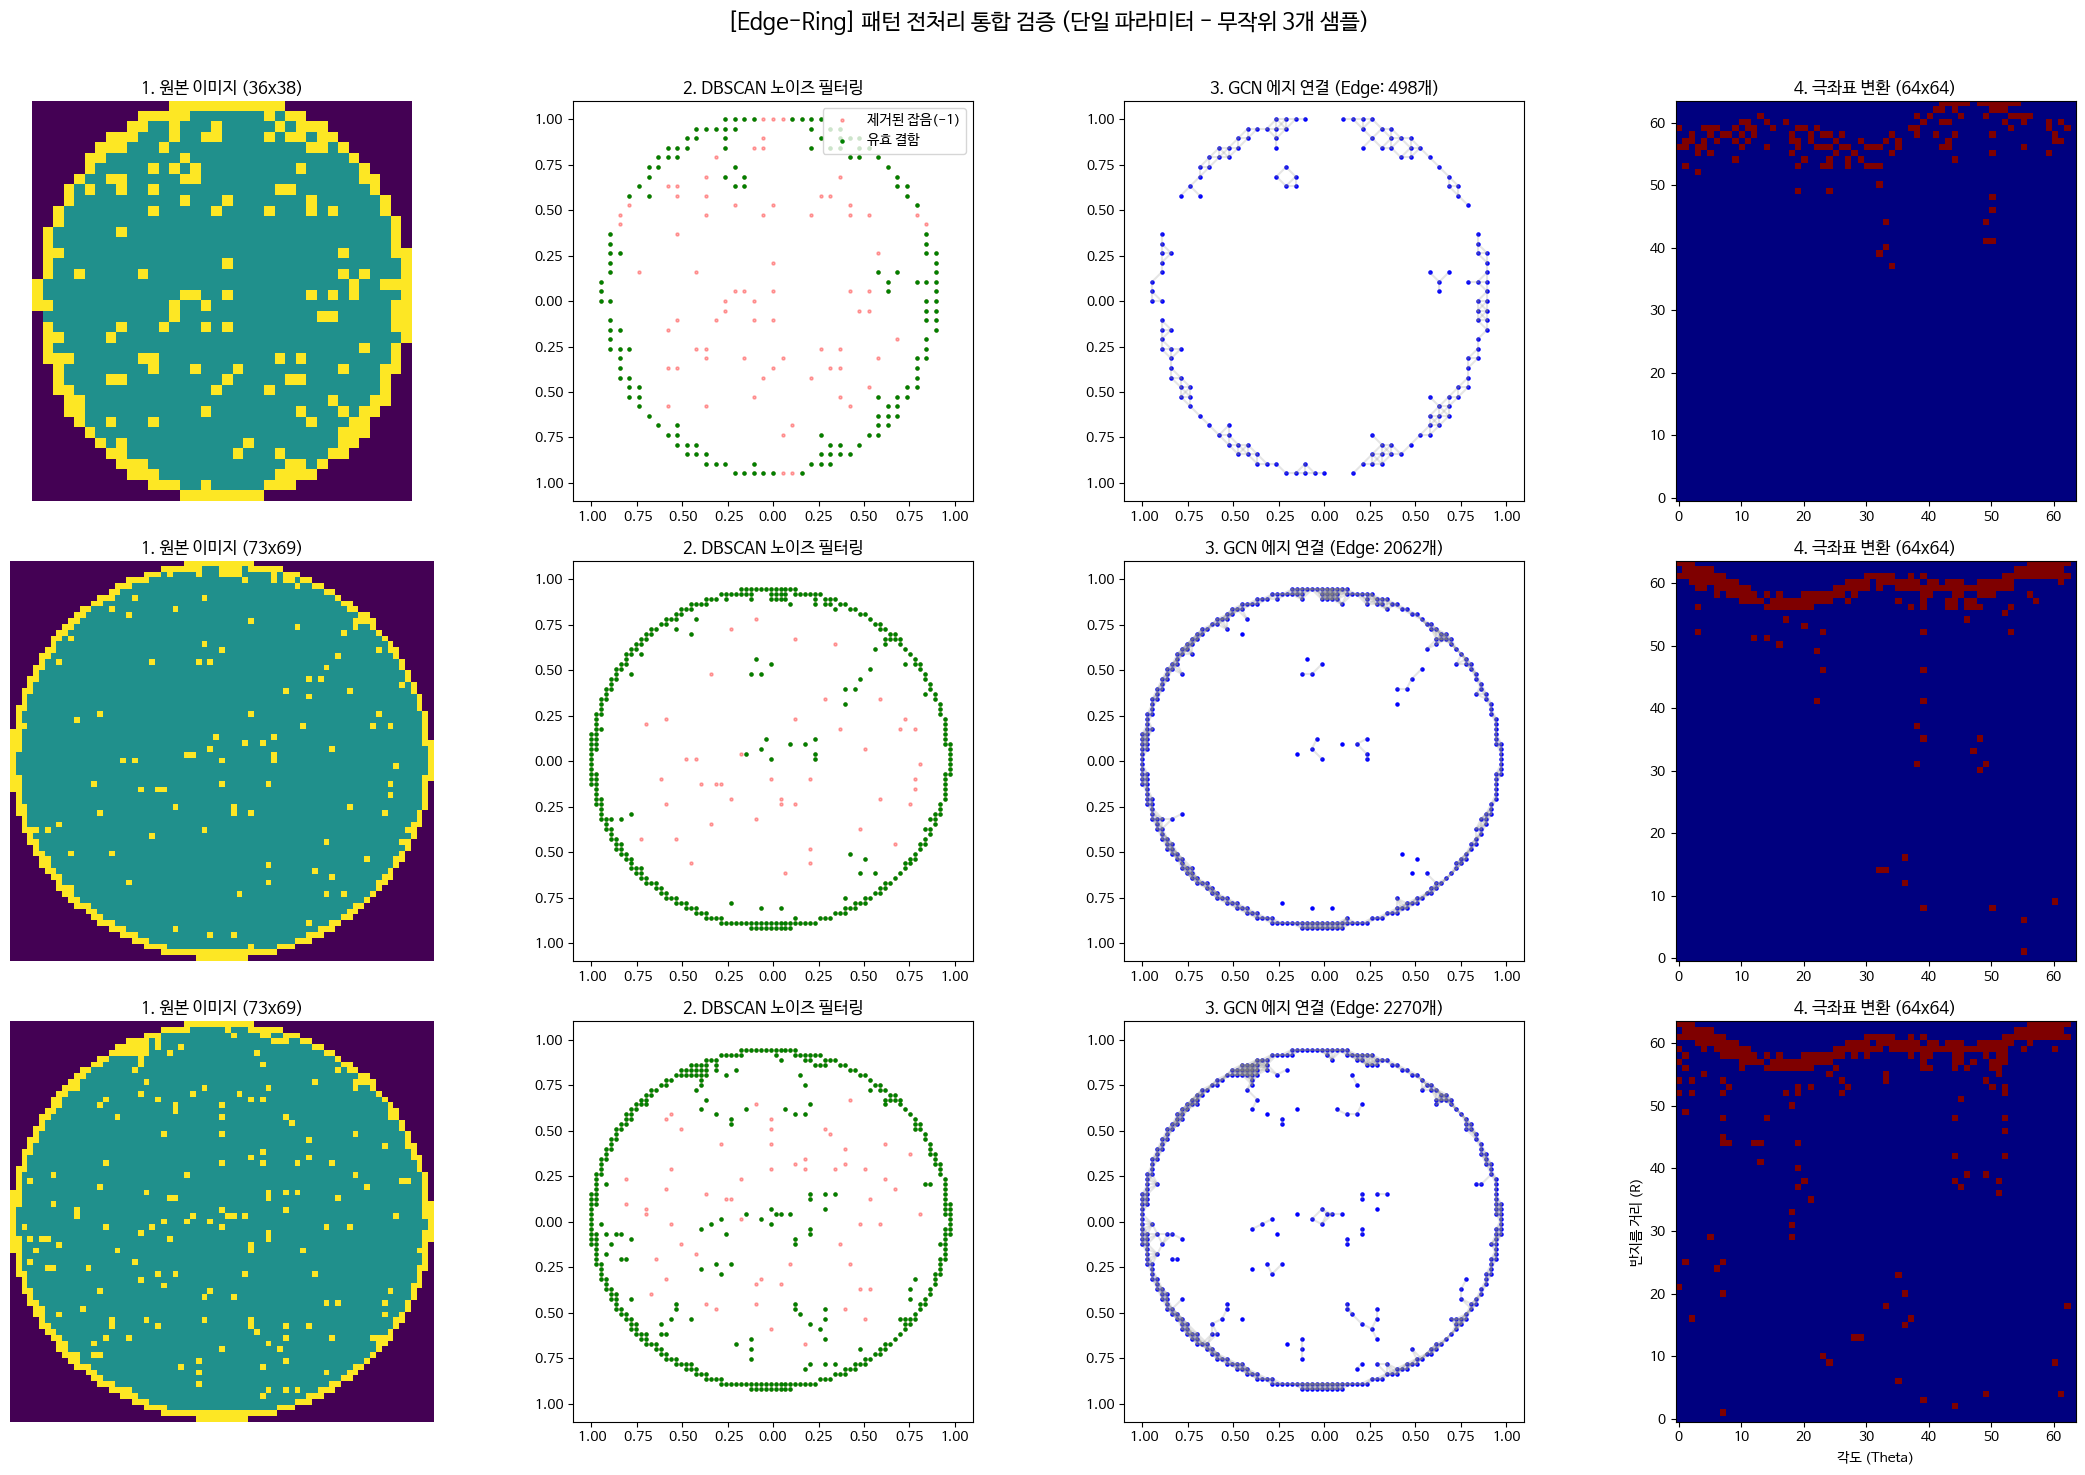

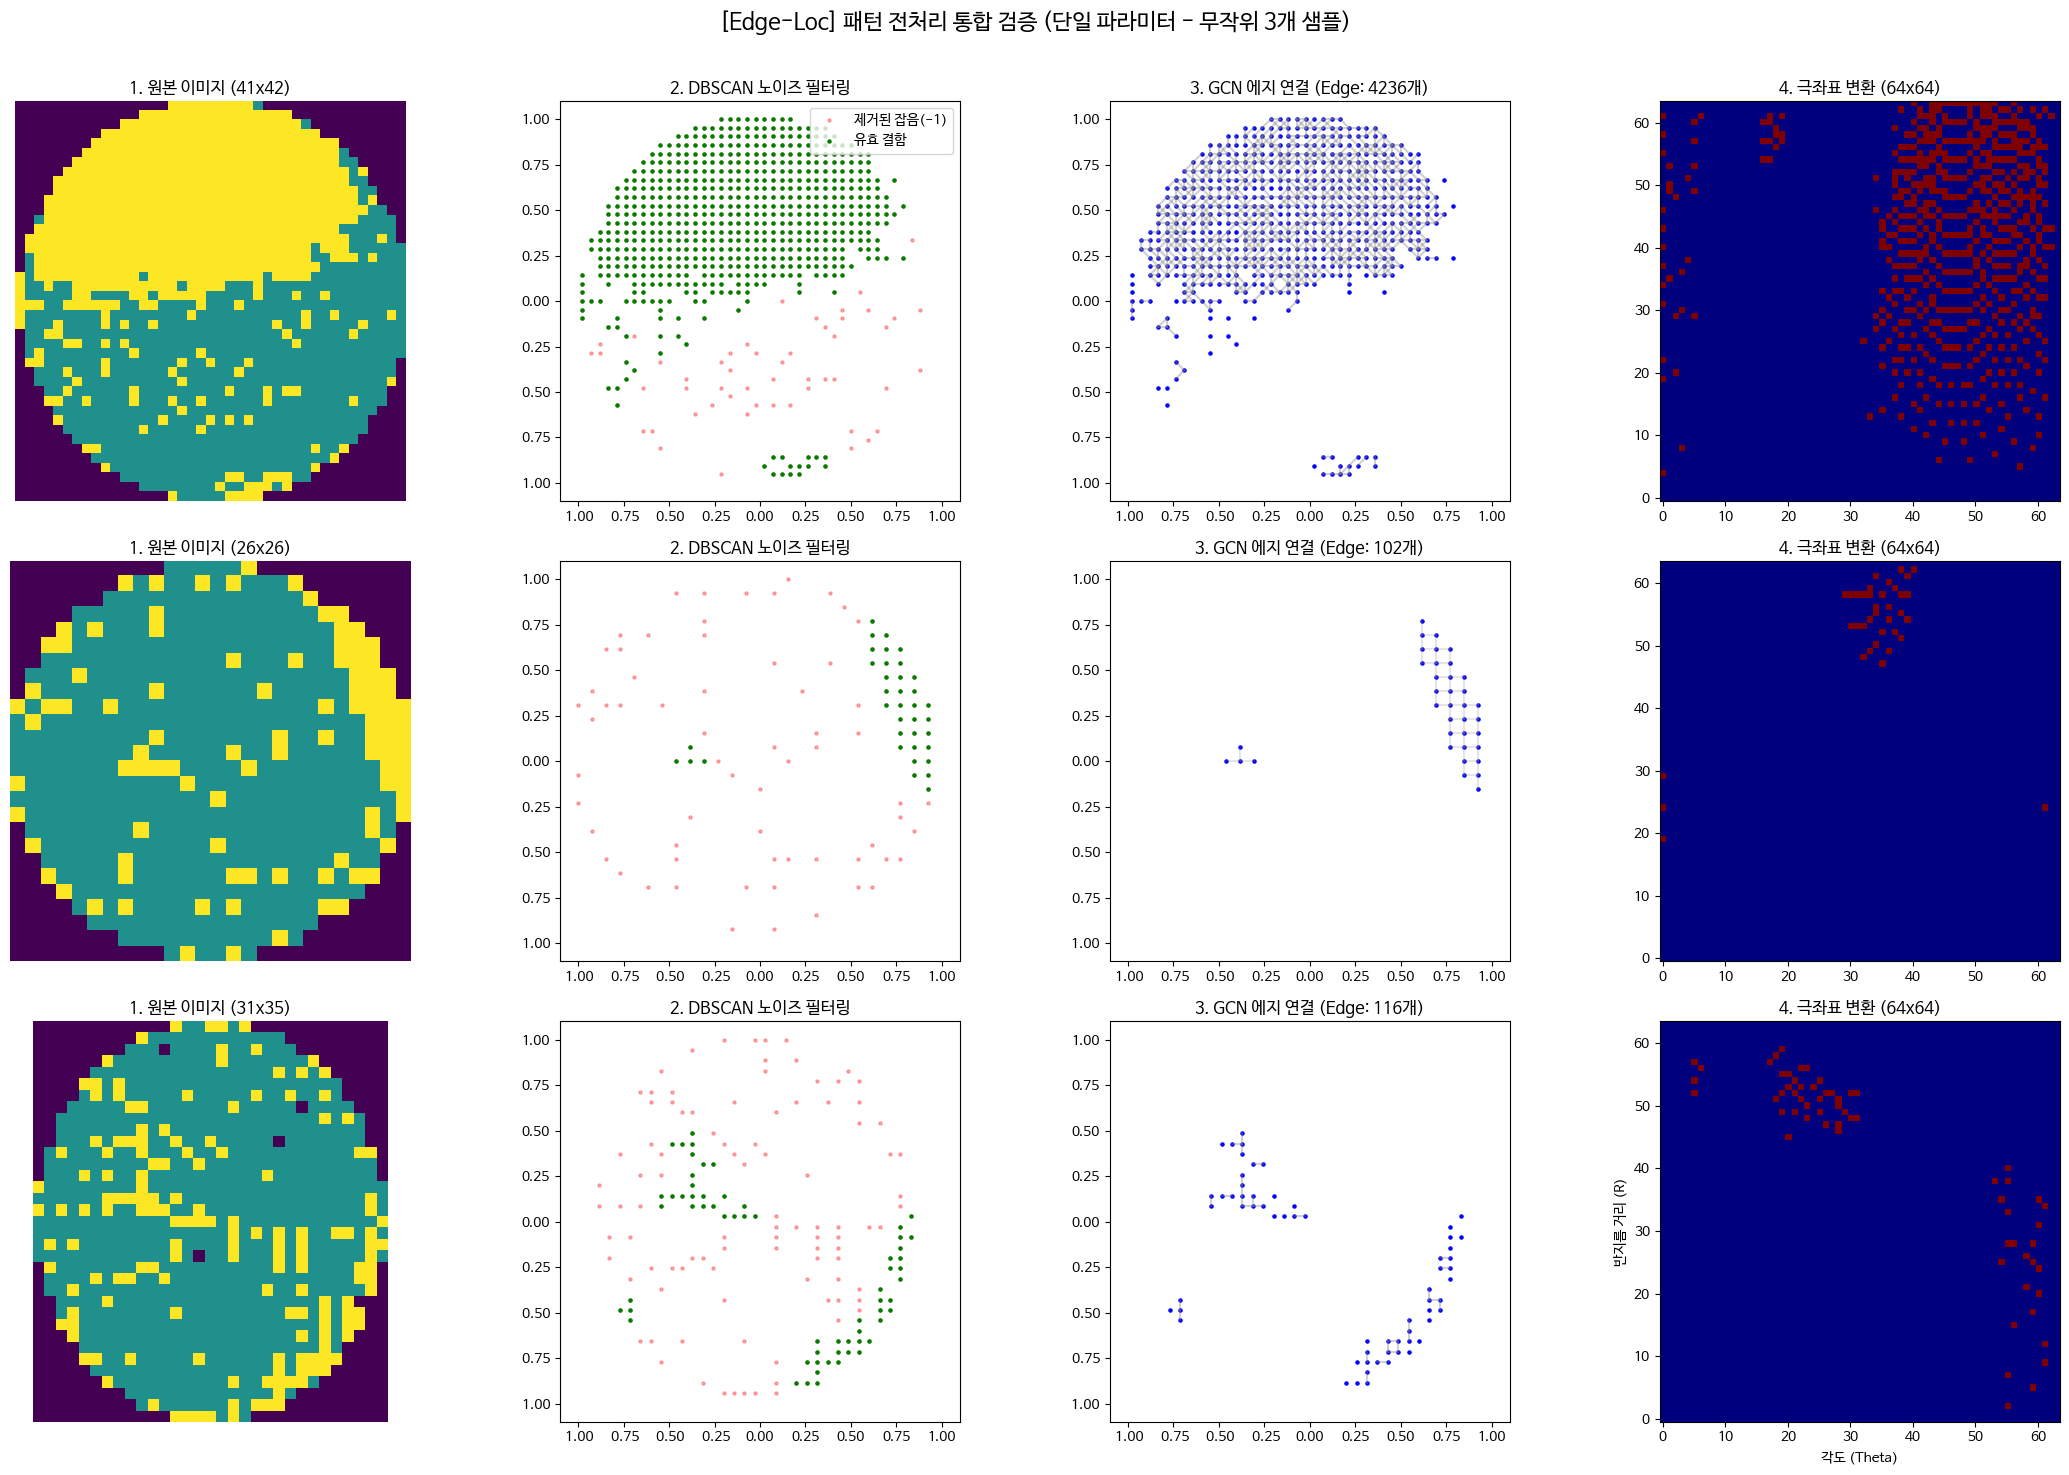

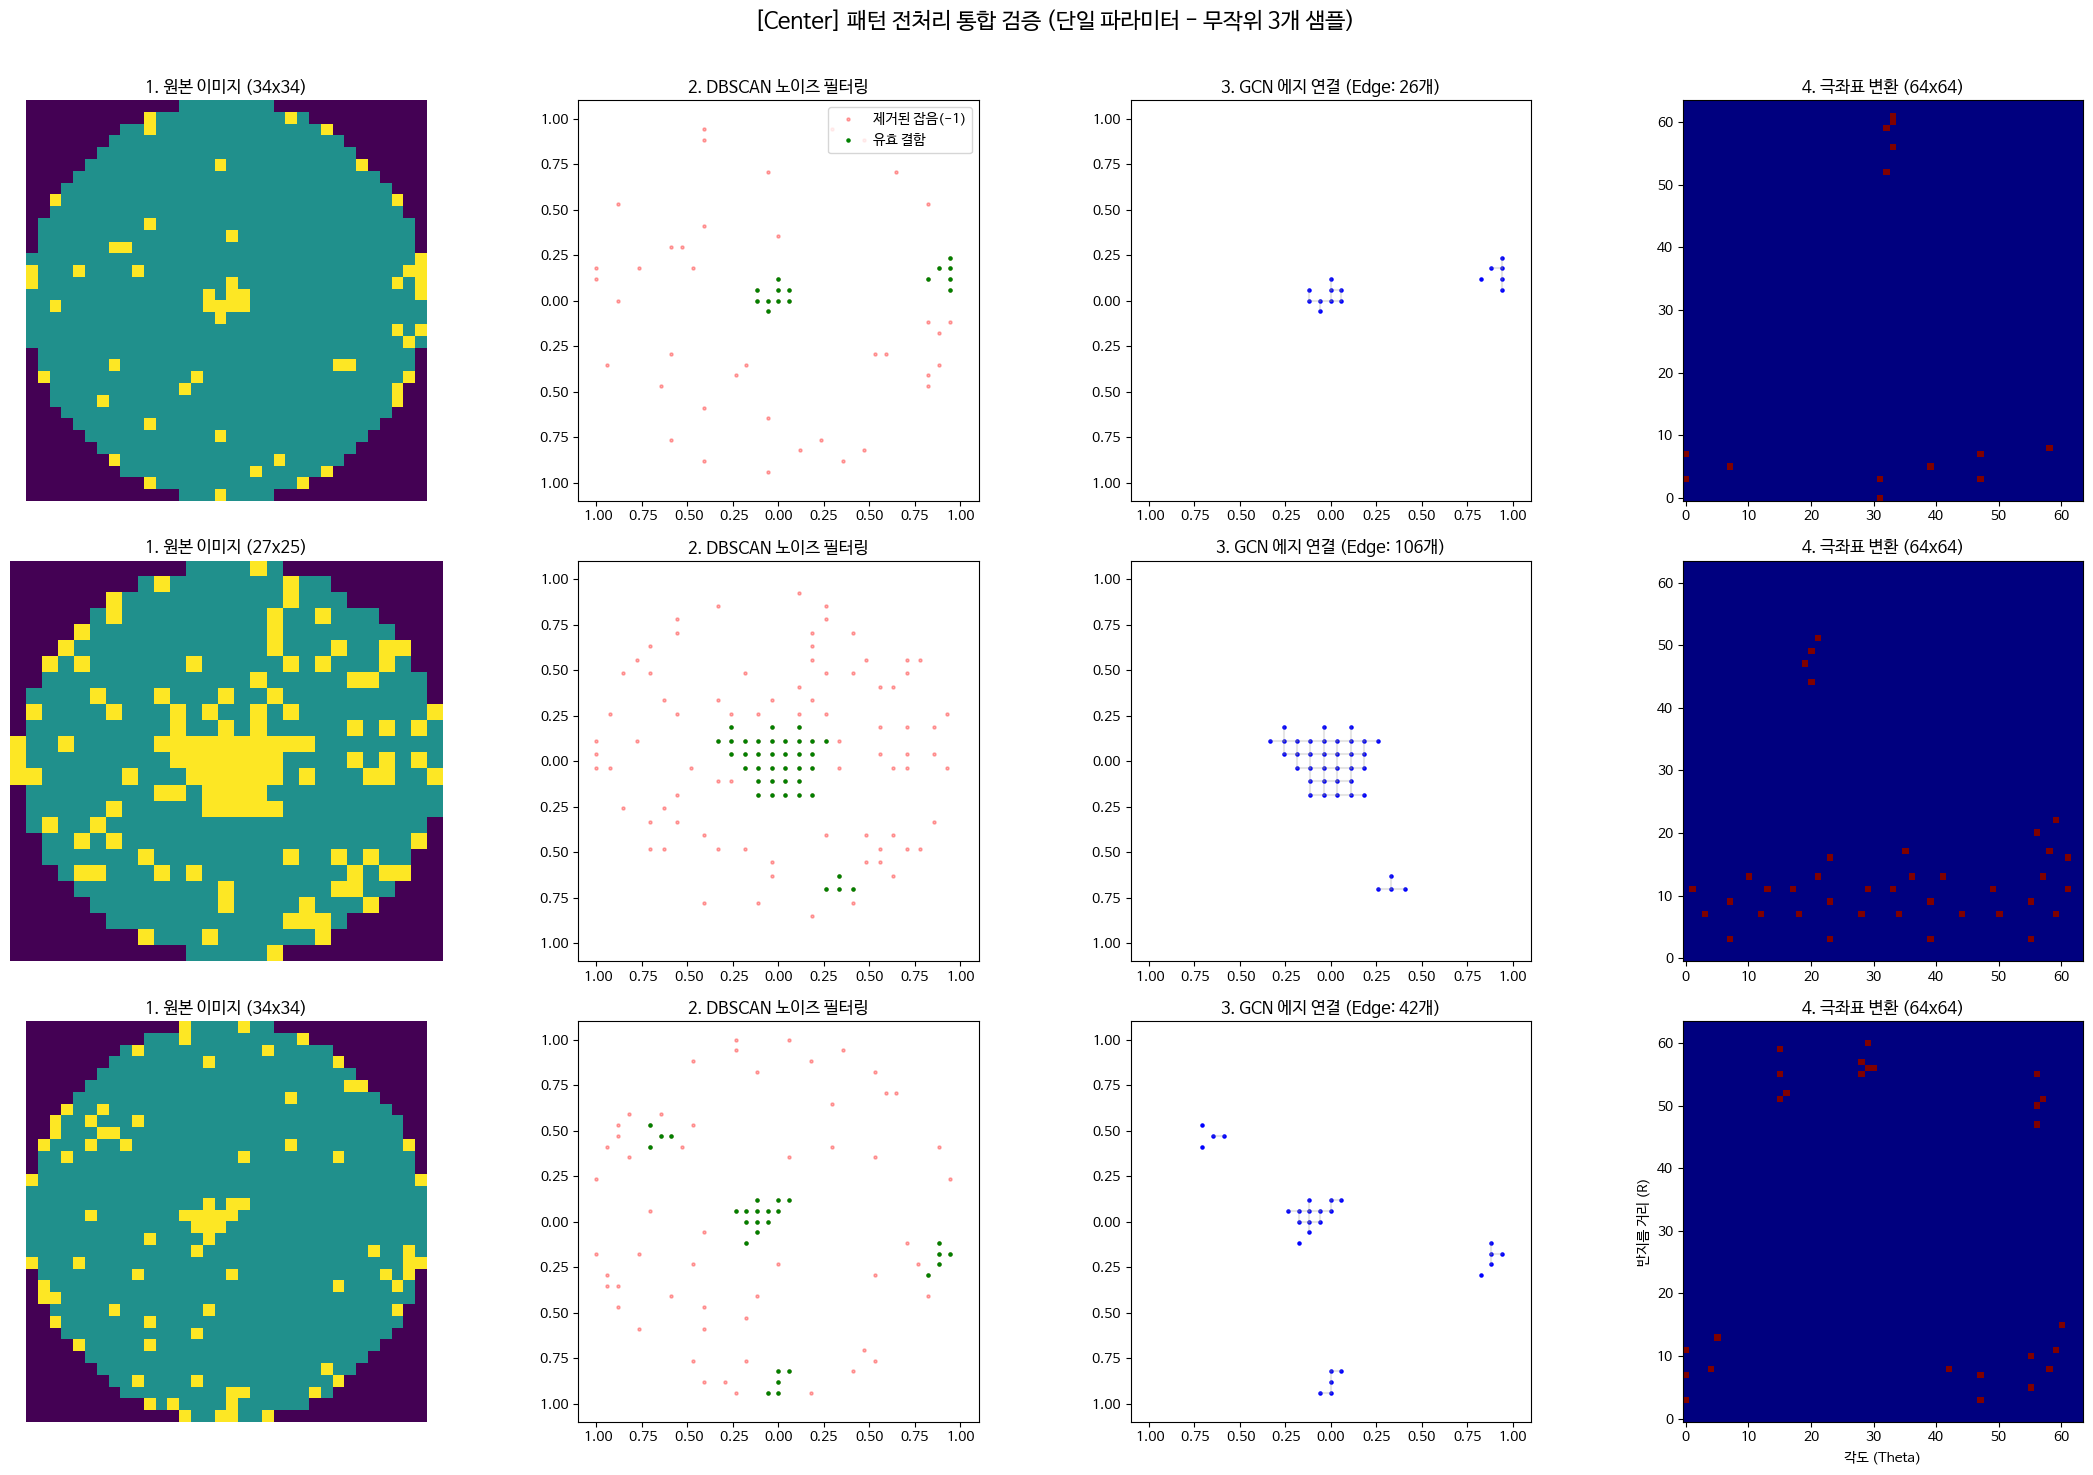

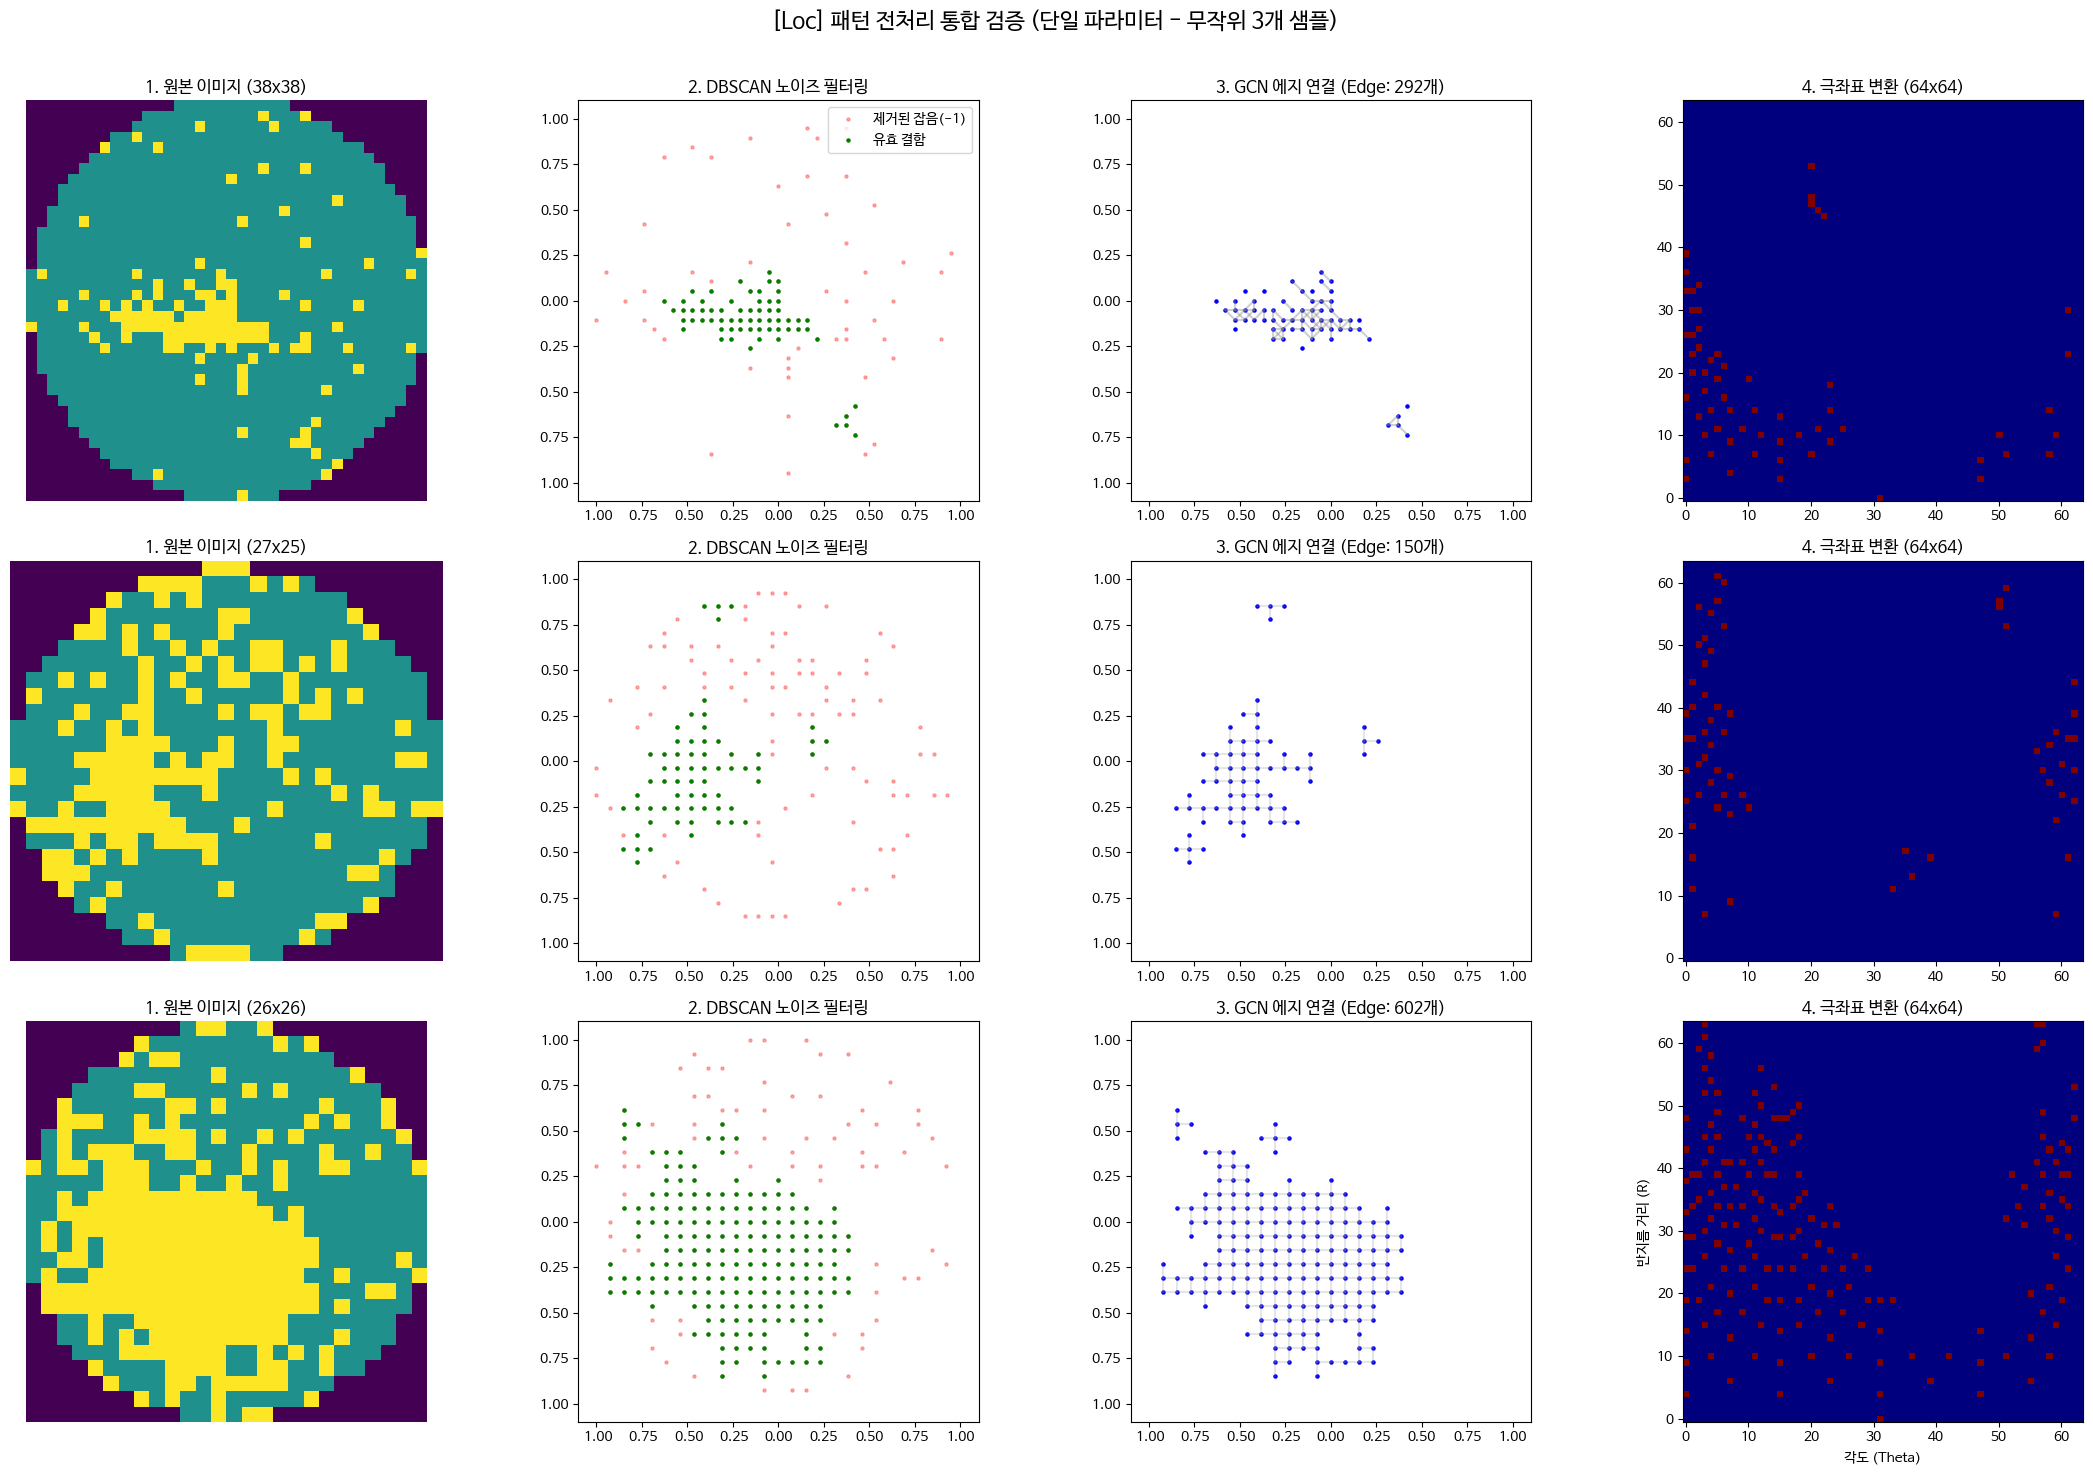

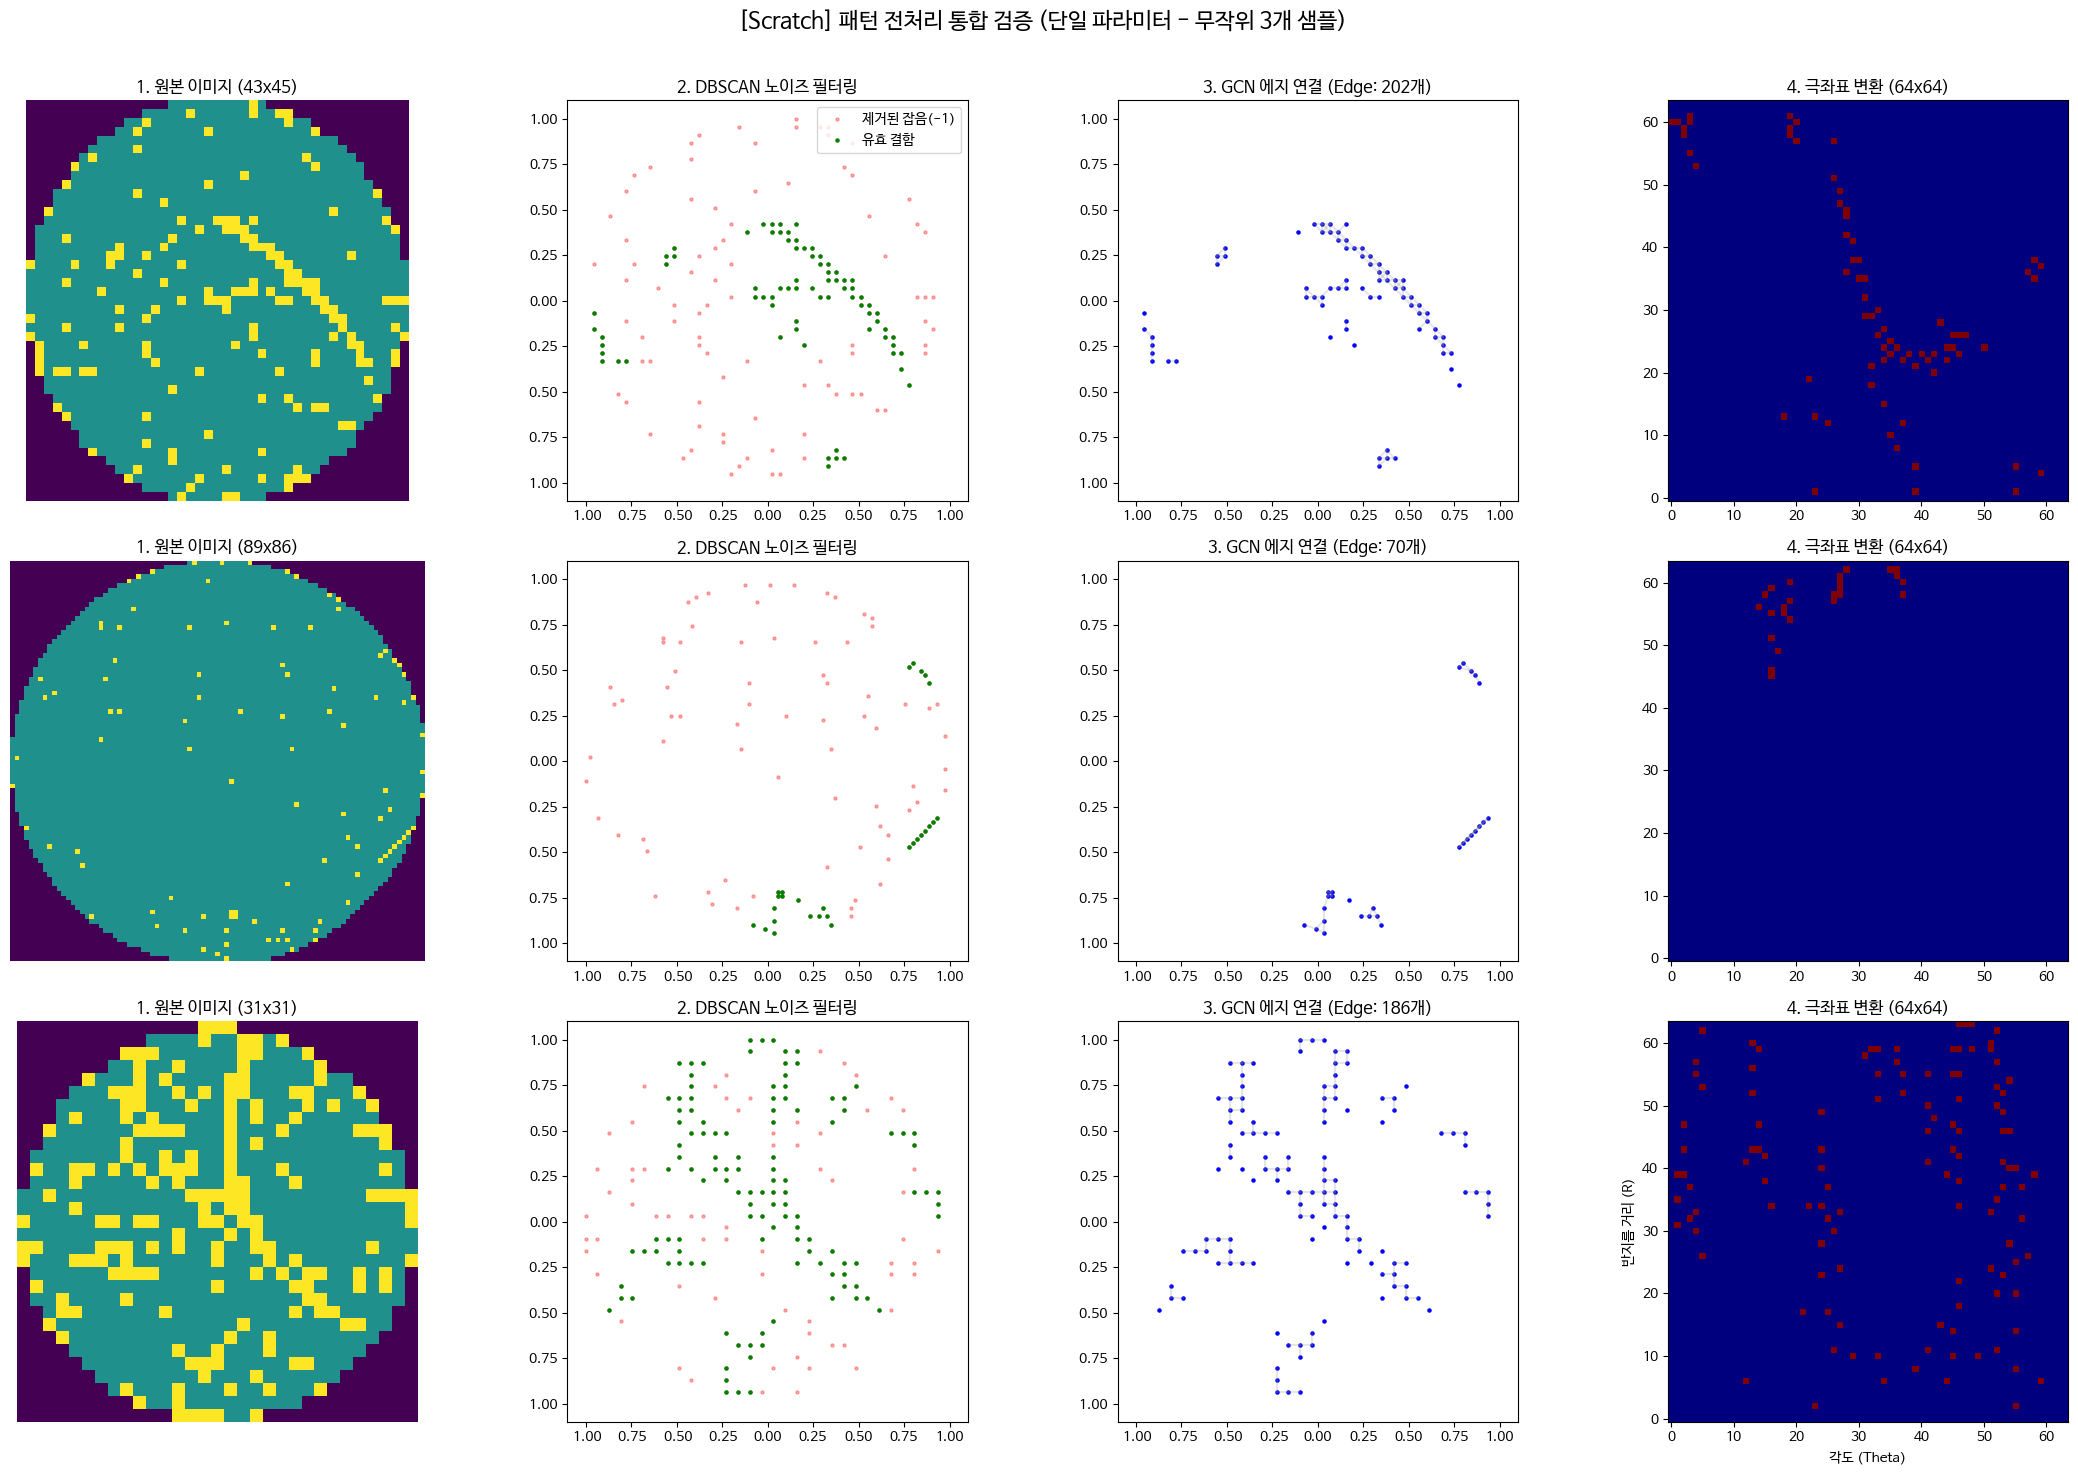

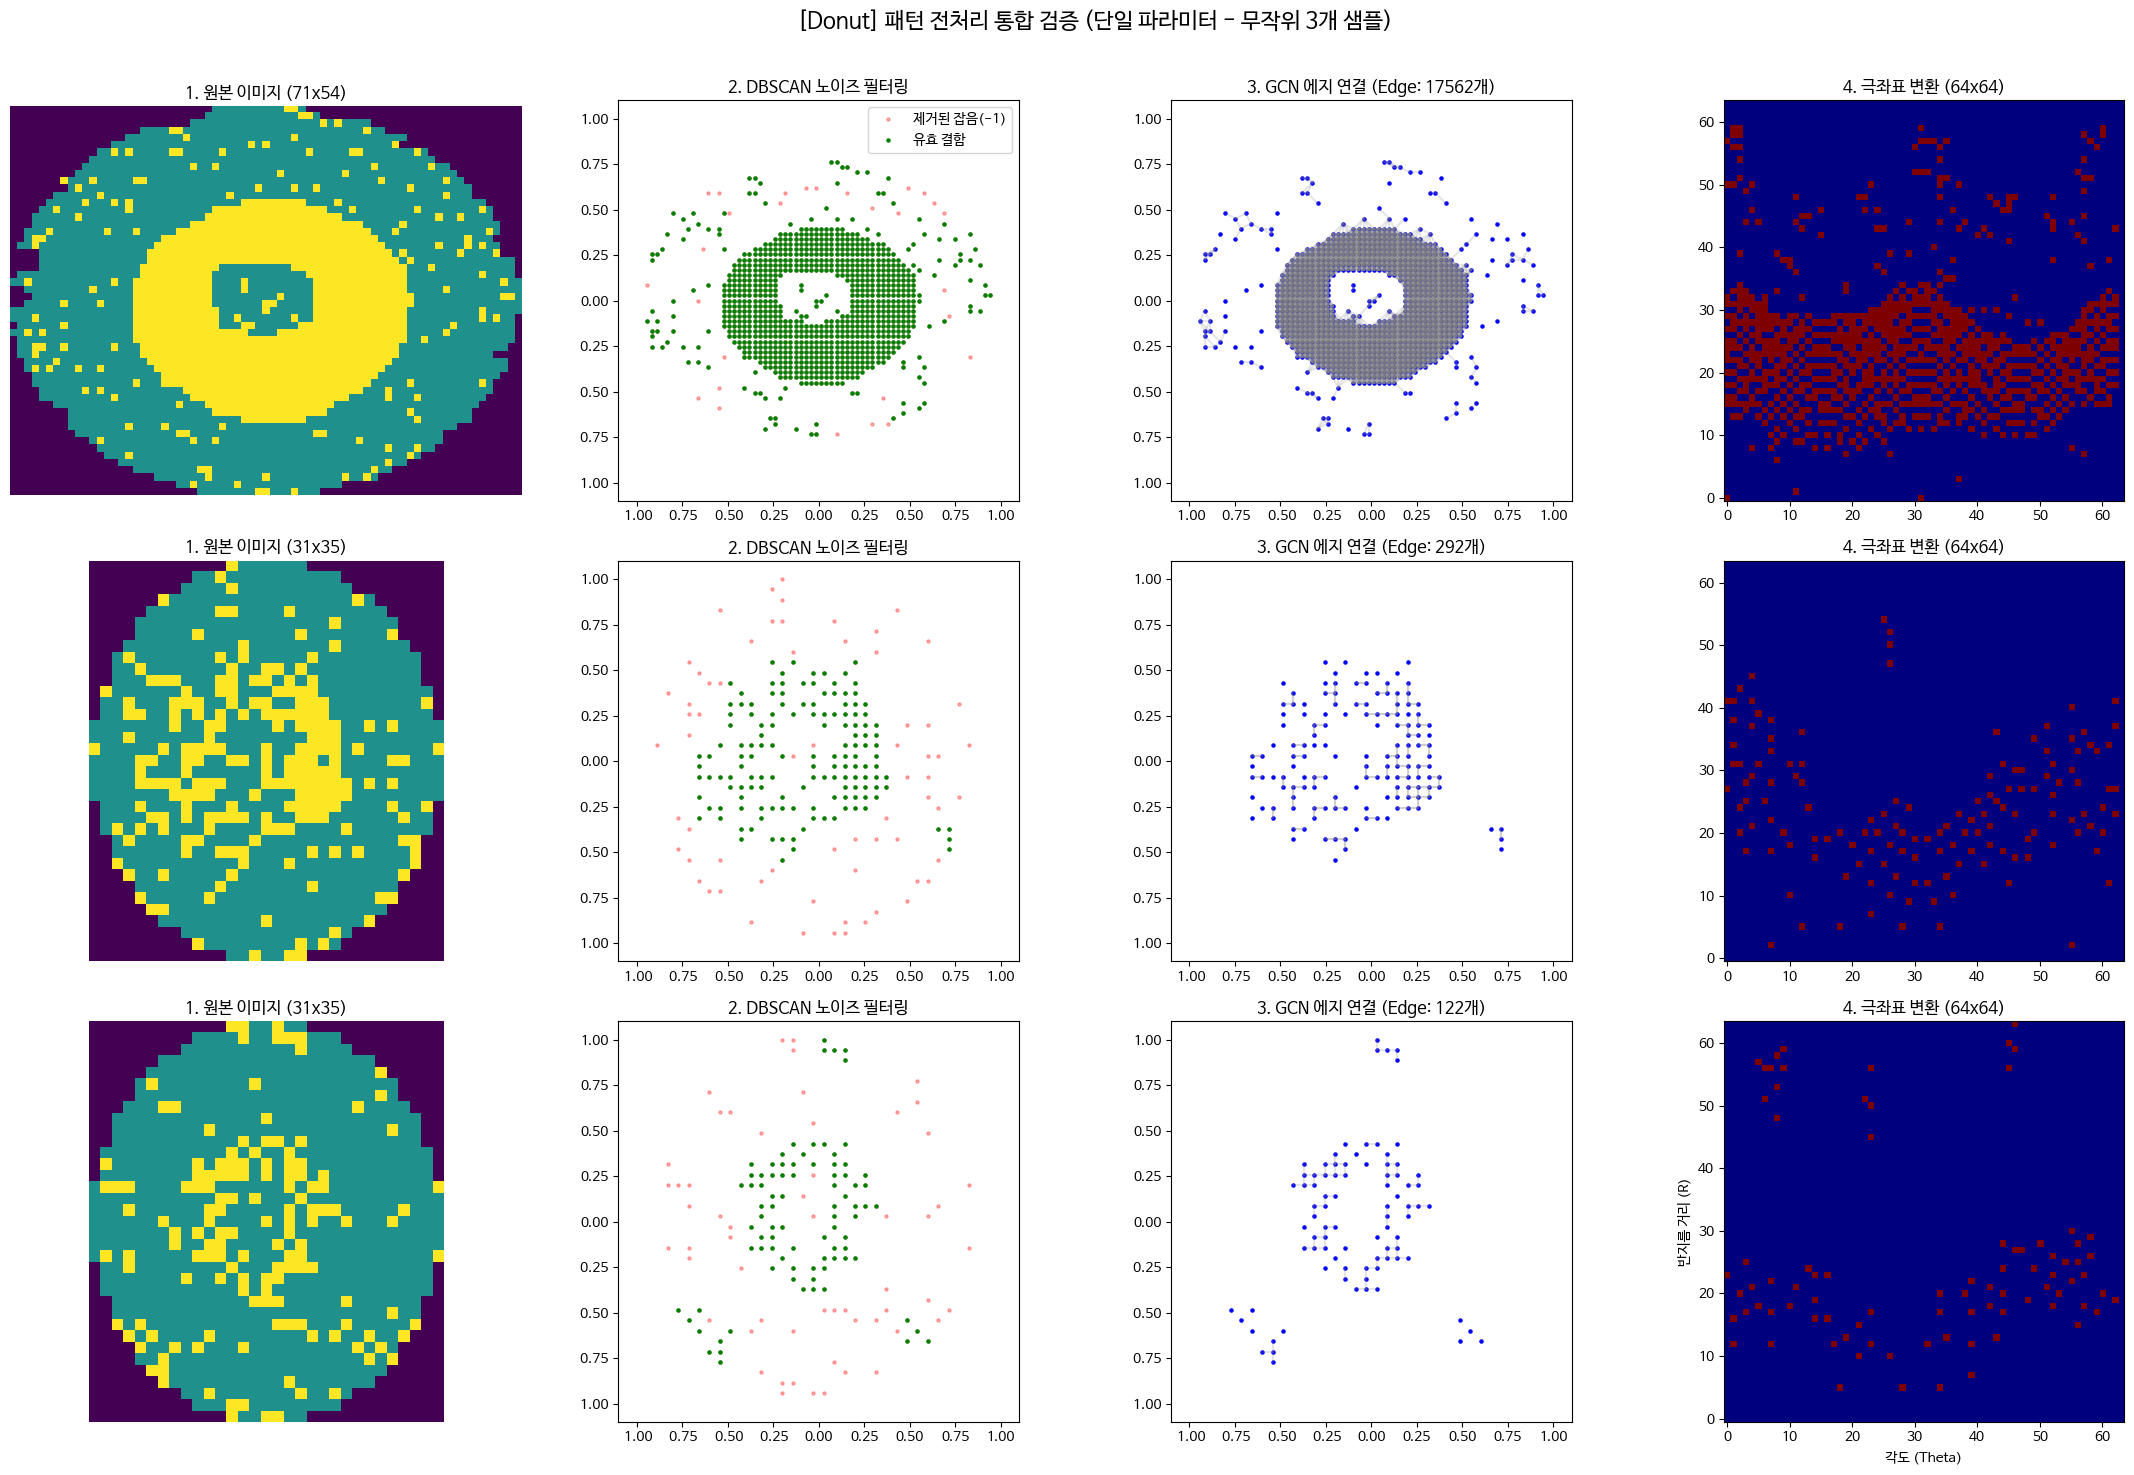

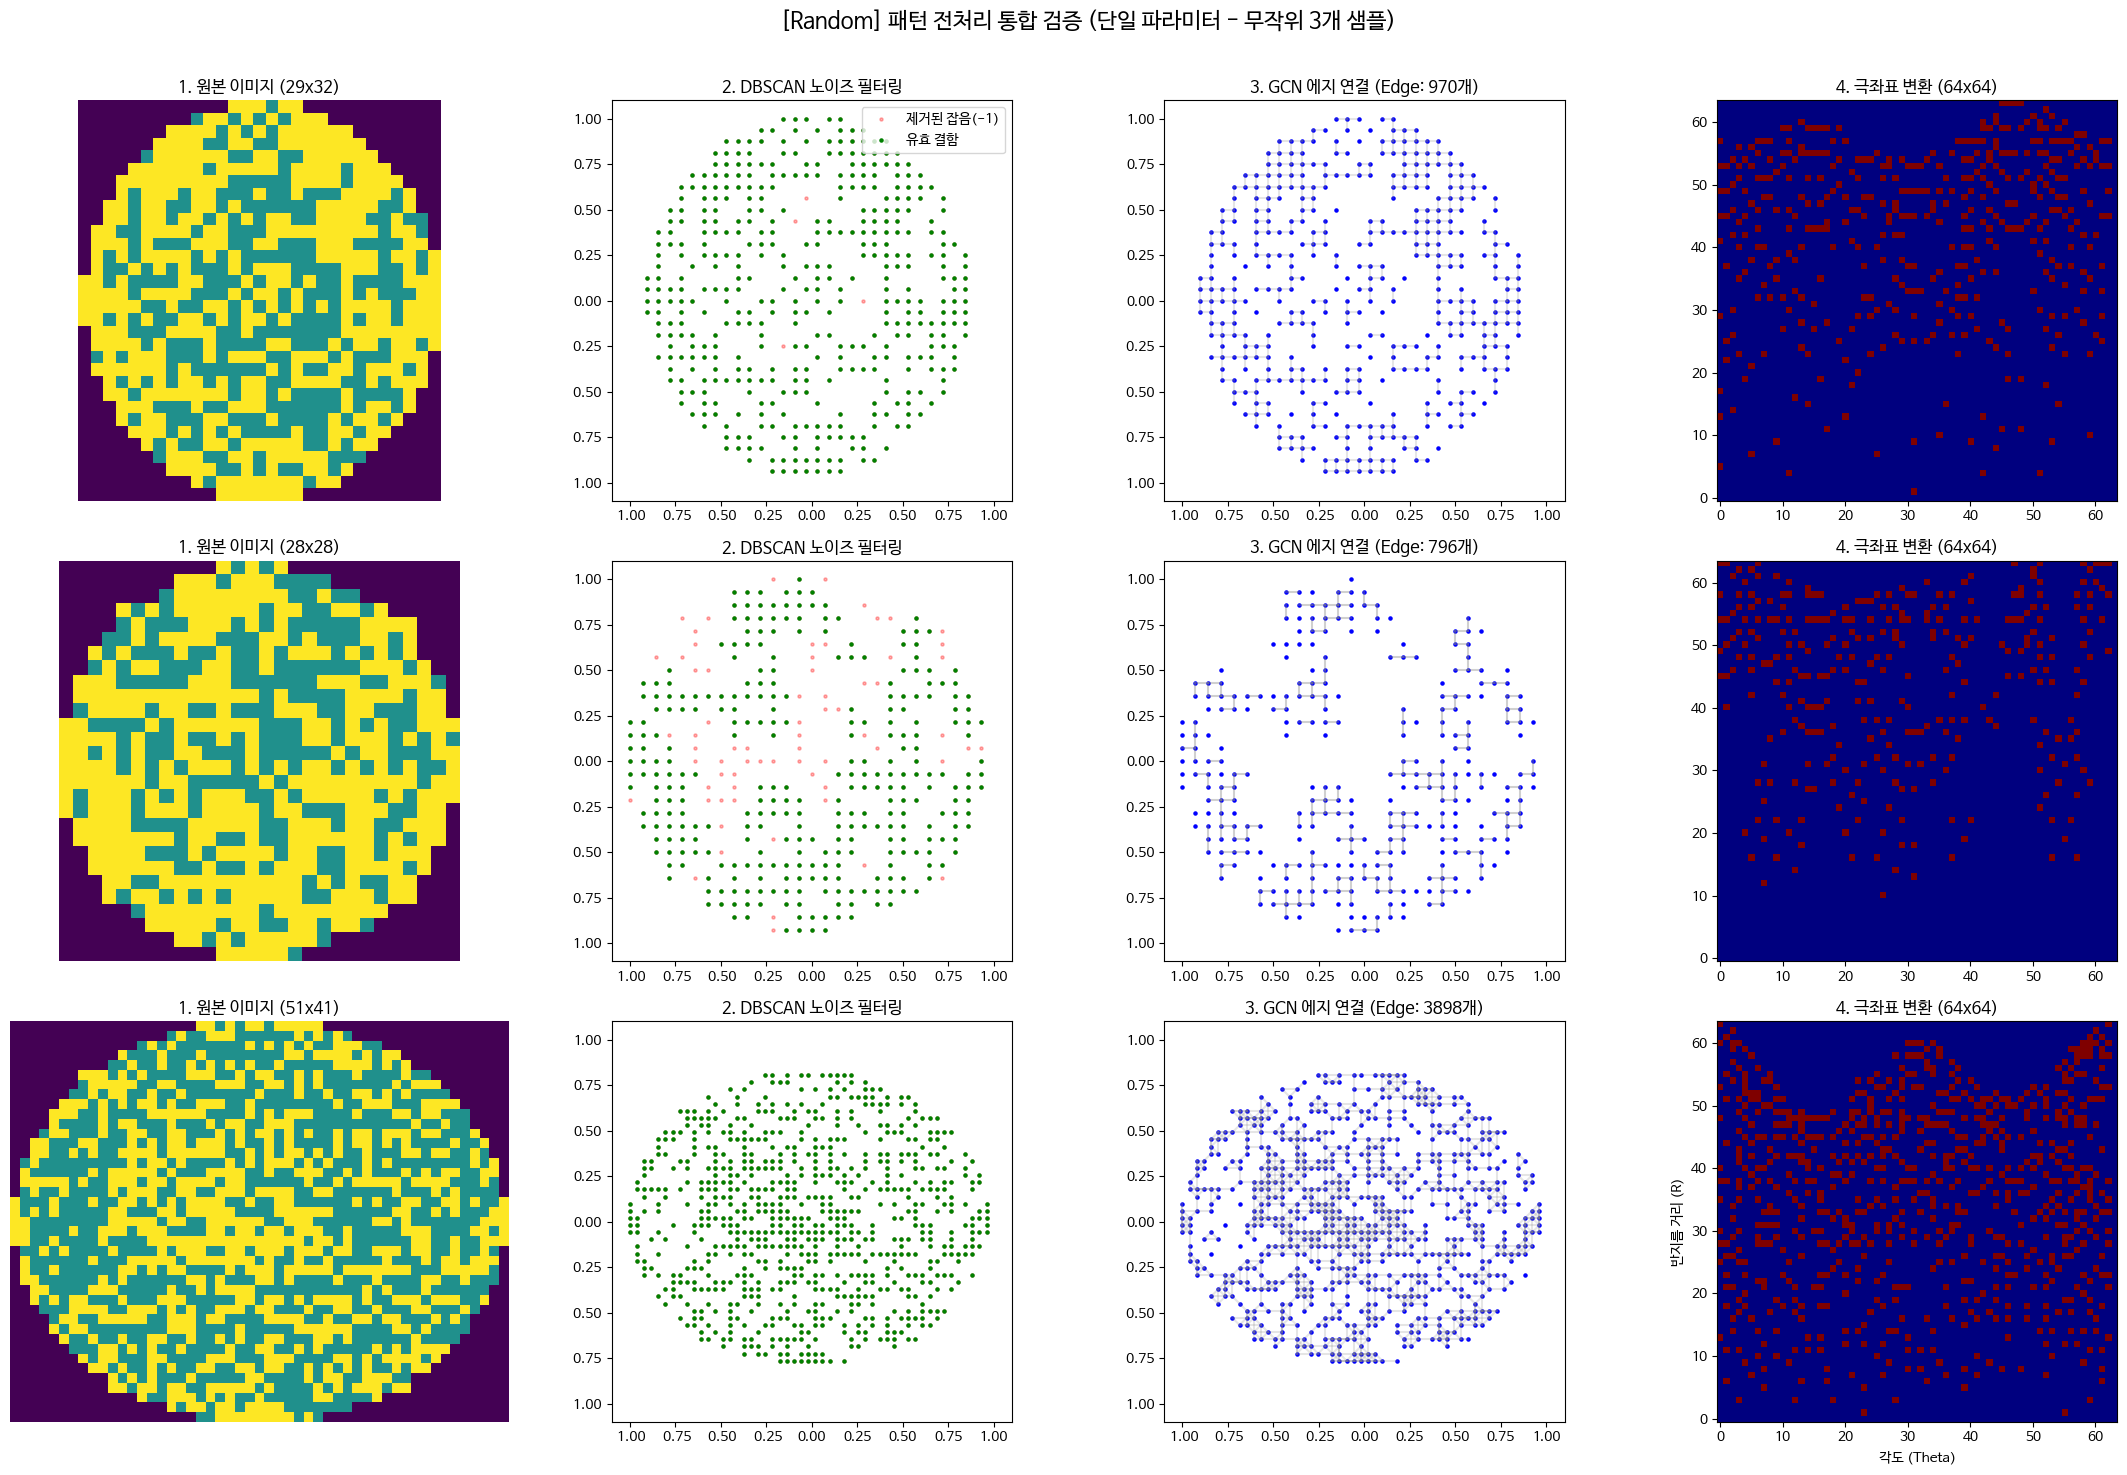

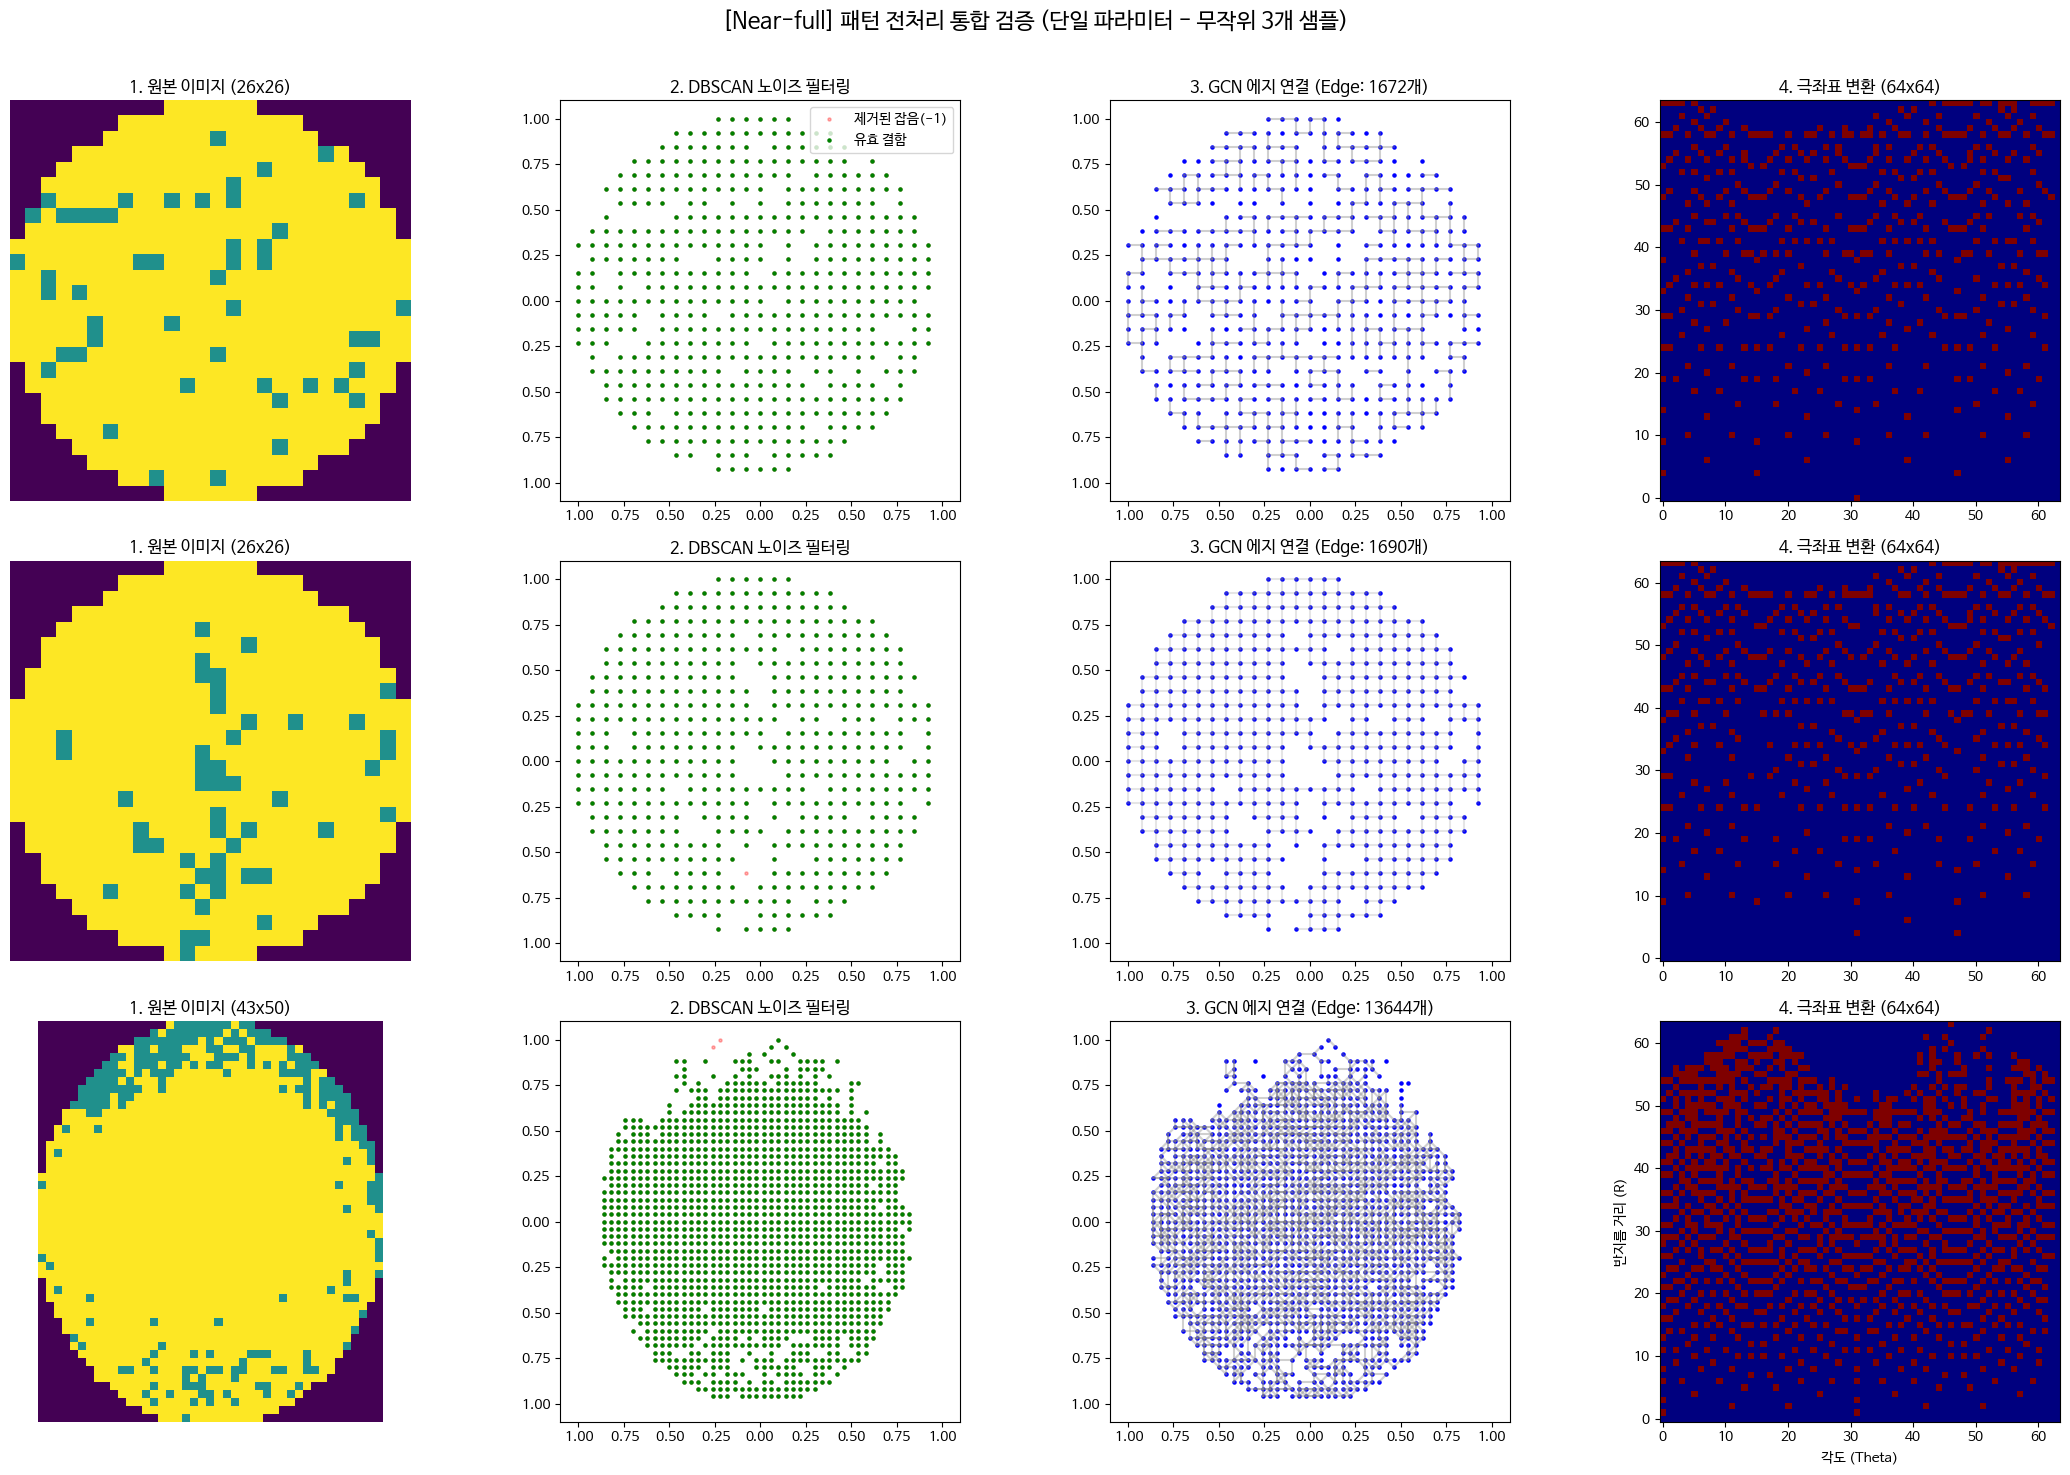

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

def visualize_preprocessed_results_v3_samples(df, defect_types, n_samples=3):
    """
    단일 파라미터(UNIFIED_EPS 등)를 적용하여, 각 결함 패턴별로 무작위 n_samples 개수를 뽑아
    4단계 전처리 결과를 비교 시각화하는 함수 (무작위 샘플링 기능 유지)
    """
    for f_type in defect_types:
        # 1. 해당 불량 패턴 데이터 필터링
        subset = df[df['failureType'] == f_type]
        if len(subset) == 0:
            print(f"⚠️ {f_type} 패턴: 데이터가 존재하지 않습니다.")
            continue

        # 데이터가 요구하는 샘플 수보다 적을 경우 방어 로직
        actual_n = min(len(subset), n_samples)

        # 2. 무작위 샘플 추출 (실행할 때마다 다른 웨이퍼가 선택됨)
        samples = subset.sample(n=actual_n)

        # 3. 동적 시각화 캔버스 준비 (세로: 샘플 수, 가로: 4단계)
        fig, axes = plt.subplots(actual_n, 4, figsize=(22, 5 * actual_n))
        fig.suptitle(f'[{f_type}] 패턴 전처리 통합 검증 (단일 파라미터 - 무작위 {actual_n}개 샘플)', fontsize=16, fontweight='bold')

        # 단일 파라미터 전처리기 생성 (삭제된 pattern_standards 대신 단일 변수 사용)
        preprocessor = WaferPreprocessor(
            eps=UNIFIED_EPS,
            min_samples=UNIFIED_MIN_SAMPLES,
            edge_radius=UNIFIED_EDGE_RADIUS
        )

        # 축(axes)이 1차원 배열(샘플 1개)일 경우 2차원으로 차원 확장
        if actual_n == 1:
            axes = np.expand_dims(axes, axis=0)

        # 4. 각 샘플별 4단계 시각화 진행
        for row_idx, (idx, sample) in enumerate(samples.iterrows()):
            wafer_map = sample['waferMap']

            # 전처리 엔진 가동
            processed = preprocessor.process_wafer(wafer_map)

            if processed is None:
                axes[row_idx, 0].set_title("⚠️ 유효 결함 추출 실패 (None)")
                axes[row_idx, 0].axis('off')
                for col in range(1, 4): axes[row_idx, col].axis('off')
                continue

            # 원본 좌표 추출 (시각화용)
            bad_y, bad_x = np.where(wafer_map == 2)
            h, w = wafer_map.shape
            coords = np.column_stack(((bad_x - w/2)/(max(w,h)/2), -(bad_y - h/2)/(max(w,h)/2)))

            # [Step 1] 원본 행렬 이미지
            axes[row_idx, 0].imshow(wafer_map, cmap='viridis')
            axes[row_idx, 0].set_title(f'1. 원본 이미지 ({w}x{h})')
            axes[row_idx, 0].axis('off')

            # [Step 2] DBSCAN 노이즈 필터링
            axes[row_idx, 1].scatter(coords[:,0], coords[:,1], c='red', s=5, alpha=0.3, label='제거된 잡음(-1)' if row_idx == 0 else "")
            clean_coords = processed['graph_x'].numpy()
            axes[row_idx, 1].scatter(clean_coords[:,0], clean_coords[:,1], c='green', s=5, label='유효 결함' if row_idx == 0 else "")
            axes[row_idx, 1].set_title('2. DBSCAN 노이즈 필터링')
            axes[row_idx, 1].set_xlim(-1.1, 1.1); axes[row_idx, 1].set_ylim(-1.1, 1.1); axes[row_idx, 1].set_aspect('equal')
            if row_idx == 0: axes[row_idx, 1].legend(loc='upper right')

            # [Step 3] GCN 구조
            axes[row_idx, 2].scatter(clean_coords[:,0], clean_coords[:,1], c='blue', s=5)
            edge_idx = processed['edge_index'].numpy()
            for i in range(0, edge_idx.shape[1], 2):
                axes[row_idx, 2].plot([clean_coords[edge_idx[0,i],0], clean_coords[edge_idx[1,i],0]],
                                    [clean_coords[edge_idx[0,i],1], clean_coords[edge_idx[1,i],1]], 'gray', alpha=0.2)
            axes[row_idx, 2].set_title(f'3. GCN 에지 연결 (Edge: {edge_idx.shape[1]}개)')
            axes[row_idx, 2].set_xlim(-1.1, 1.1); axes[row_idx, 2].set_ylim(-1.1, 1.1); axes[row_idx, 2].set_aspect('equal')

            # [Step 4] 극좌표 변환
            axes[row_idx, 3].imshow(processed['polar_image'].squeeze().numpy(), cmap='jet', origin='lower')
            axes[row_idx, 3].set_title('4. 극좌표 변환 (64x64)')
            if row_idx == actual_n - 1:
                axes[row_idx, 3].set_xlabel('각도 (Theta)'); axes[row_idx, 3].set_ylabel('반지름 거리 (R)')

        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

# ==========================================
# 실행 부분
# ==========================================
target_defects = ['Edge-Ring', 'Edge-Loc', 'Center', 'Loc', 'Scratch', 'Donut', 'Random', 'Near-full']

# 함수 실행 (실행할 때마다 새로운 3개의 무작위 웨이퍼가 시각화됩니다)
visualize_preprocessed_results_v3_samples(df_defects, target_defects, n_samples=3)